# SPArrOW pipeline - Xenium

In this series of notebooks, we will analyze a 10X Genomics [Xenium](https://www.10xgenomics.com/platforms/xenium) dataset using the SPArrOW pipeline, a flexible, modular and scalable analysis pipeline that includes tools for image processing, cell segmentation, transcript allocation and cell type annotation. We will also explore the Xenium dataset itself, introduce the SpatialData data format and how you can plot spatial data, and go over some additional analysis options, including segmentation-free approaches and downstream analysis steps.

When you make use of the SPArrOW pipeline tools, please cite [Pollaris et al. (2024)](https://www.biorxiv.org/content/biorxiv/early/2024/07/06/2024.07.04.601829.full.pdf) and the Harpy paper (accepted for publication in Bioinformatics).

## Import packages

In [ ]:
import spatialdata as sd
import spatialdata_io
import spatialdata_plot
import harpy as hp
import matplotlib.pyplot as plt
import numpy as np
import dask.array as da
import os
import pandas as pd
import geopandas as gpd
import scanpy as sc
import squidpy as sq

## Read SpatialData

In [ ]:
# Specify paths
input_path =  "/data/groups/technologies/spatial.catalyst/Training/training_data/Xenium_Ovarian_Cancer_FFPE/data/Xenium_Prime_Ovarian_Cancer_FFPE_XRrun_outs" # Set input path to the output directory of Xenium Onboard Analysis
output_path = "/data/groups/technologies/spatial.catalyst/Training/training_data/Xenium_Ovarian_Cancer_FFPE/analysis/harpy" # Set a path to save the output from Harpy

cropped_zarr_path = os.path.join(output_path, 'cropped_sdata.zarr')

In [ ]:
sdata = sd.read_zarr(cropped_zarr_path)

## 6. Image preprocessing
To improve segmentation quality, we have several options to first preprocess the images to improve the quality, contrast, remove background, etc. This can help to get much better segmentation masks, but note that in many cases (depending on the exact combination of image quality, tissue type and segmentation model), we can safely skip this step and get good results with just the raw images.

### 6.1 Tiling correction and inpainting

<b>Tiling correction</b>: For some imaging-based spatial transcriptomics technologies (such as Molecular Cartography), uneven illumination during image acquisition results in artifacts that can influence the downstream analysis (e.g. segmentation). Harpy's tiling_correction function can be used to correct for this uneven illumination (using BaSiC on the back-end).

<b>Inpainting</b>: For Molecular Cartography and CosMx, there are black lines at the border between tiles and these can causing incorrect segmentation of cells. The tiling_correction function can correct for these black lines by using OpenCV's inpainting. 

We have not found this step to be necessary for most technologies (Xenium, Merscope, ...), but you should plot the image to check whether you need this preprocessing step for your data. 

To use hp.im.tiling_correction(), make sure `jax` and `basicpy` are installed as described in the [documentation](https://harpy.readthedocs.io/en/latest/installation.html).

In [ ]:
sdata

In [ ]:
# First, we check whether we need any tiling correction by plotting images
from matplotlib.colors import Normalize

channels = ['DAPI', 'ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin']

fig, axes = plt.subplots(2, 2, figsize=(15, 15)) 

for ax, channel in zip(axes.ravel(), channels):
    norm = Normalize(vmin=0, vmax=5000)
     
    sdata.pl.render_images(
        element='morphology_focus_global', channel=channel, cmap="gray", norm=norm
    ).pl.show(
        coordinate_systems="global",
        title=channel,
        colorbar=False,
        ax=ax
    )

In [ ]:
# Since we do not see any tiling artifacts (black lines, uneven illumination), we do not need to apply tiling correction. Therefore, the code is commented out.

'''
sdata, flatfields = hp.im.tiling_correction(
    sdata = sdata,
    img_layer = "morphology_focus_global",
    tile_size = 2144, # You need to supply the tile size that was used during acquisition. For Molecular Cartography datasets, the tile size is 2144.
    output_layer = "tiling_correction",
    crd = None,
    overwrite=True,
)
'''

In [ ]:
# NOTE for Arne: It might be better to split up tiling_correction into two separate functions (illumination correction and inpainting) or it could be an argument in the function.

### 6.2 Min-max filtering and contrast enhancing
The next preprocessing steps include:

- A min max filter can be added. The goal of this function is to substract background noise and make the borders of the nuclei/cells cleaner. It will also remove some debris. Note that if you set the size of the filter too small (smaller then the size of your nuclei), the function will create "donuts" (black spots in the center of your cells). If the size of the min max filter is chosen too big, not enough background will be subtracted. Generally, you want to aim for the average nucleus size and some fine-tuning may be necessary.

- We also recommend to perform contrast enhancement on your image. Harpy does this by using histogram equalization (CLAHE function). The amount of correction needed can be decided by adapting the contrast_clip value. If the image is already quite bright, 3.5 might be a good starting point. For dark images, you can go up to 10 or even more. Make sure at the end the whole image is evenly illuminated and no cells are dark in the background.
 
If you think your data needs further image processing steps, you can perform these using the map_image function (see further).

In [ ]:
# First, we plot the raw images for comparison
fig, axes = plt.subplots(2, 2, figsize=(10, 10)) 

for ax, channel in zip(axes.ravel(), channels):

    norm = Normalize(vmin=0, vmax=6000)
  
    ax = hp.pl.plot_sdata(
        sdata,
        img_layer="morphology_focus_global",
        channel=channel,
        crd=(10000, 11000, 18000, 19000),
        to_coordinate_system="global",
        render_images_kwargs={"cmap": "grey", "norm": norm},
        show_kwargs={"title": channel, "colorbar": False},
        ax=ax
    )

In [ ]:
# Perform min max filtering
sdata = hp.im.min_max_filtering(
    sdata,
    img_layer = "morphology_focus_global",
    output_layer = "min_max_filtered",
    size_min_max_filter = 55, 
    overwrite = True,
)

# Plot min-max filtered images
fig, axes = plt.subplots(2, 2, figsize=(10, 10)) 

for ax, channel in zip(axes.ravel(), channels):

    norm = Normalize(vmin=0, vmax=6000)
  
    ax = hp.pl.plot_sdata(
        sdata,
        img_layer="min_max_filtered",
        channel=channel,
        crd=(10000, 11000, 18000, 19000),
        to_coordinate_system="global",
        render_images_kwargs={"cmap": "grey", "norm": norm},
        show_kwargs={"title": channel, "colorbar": False},
        ax=ax
    )

In [ ]:
# Perform contrast enhancement using CLAHE
sdata = hp.im.enhance_contrast(
    sdata,
    img_layer = "min_max_filtered",
    output_layer = "clahe",
    contrast_clip = 2.5,
    chunks = 20000,
    overwrite = True
)

# Plot contrast enhanced images
fig, axes = plt.subplots(2, 2, figsize=(10, 10)) 

for ax, channel in zip(axes.ravel(), channels):

    norm = Normalize(vmin=0, vmax=6000)
  
    ax = hp.pl.plot_sdata(
        sdata,
        img_layer="clahe",
        channel=channel,
        crd=(10000, 11000, 18000, 19000),
        to_coordinate_system="global",
        render_images_kwargs={"cmap": "grey", "norm": norm},
        show_kwargs={"title": channel, "colorbar": False},
        ax=ax
    )

<b>Excercise</b>:

- Change the `size_min_max_filter` parameter in `hp.im.min_max_filtering`. What do you see? Try some extreme values.
- Change the `enhance_contrast` parameter in `hp.im.enhance_contrast`. What do you see? Try some extreme values.

### 6.3 ADVANCED: Custom distributed preprocessing of images using `hp.im.map_image` and `Dask`

See https://docs.dask.org/en/stable/generated/dask.array.map_blocks.html and https://docs.dask.org/en/latest/generated/dask.array.map_overlap.html

Set `blockwise==True` if you want to do distributed processing using `dask.array.map_blocks` or `dask.array.map_overlap`, set `blockwise==False` if your function is already distributed (e.g. when using `dask_image` filters https://image.dask.org/en/latest/dask_image.ndfilters.html.)

In [ ]:
import numpy as np
from numpy.typing import NDArray

# Define your custom function
def _my_dummy_function(image: NDArray, parameter: int | float )->NDArray:
    # input (1,1,y,x)
    # output (1,1,y,x)
    print(f"Type of the image is: {type(image)}")
    print(image.shape)
    return image*parameter

fn_kwargs = {"parameter": 2}

# Apply custom function
sdata = hp.im.map_image(
    sdata,
    func = _my_dummy_function,
    fn_kwargs = fn_kwargs,
    img_layer = "morphology_focus_global",
    output_layer="dummy_image",
    chunks = 2048,
    blockwise = False, # if blockwise == True --> input to _my_dummy_function is a numpy array of size chunks, else it is a Dask array (with chunksize chunks)
    depth = 1000, # if blockwise == True, and depth specified, will use map_overlap instead of map_blocks for distributed processing
    overwrite = True,
    dtype = np.uint16,
    meta = np.array((), dtype=np.uint16),
)

In [ ]:
from harpy.image._image import _get_spatial_element
_get_spatial_element(sdata, layer="morphology_focus_global").data.compute()[ :, :10, :10 ]

In [ ]:
# We can see that in the dummy image, all values were multiplied by 2
_get_spatial_element(sdata, layer="dummy_image").data.compute()[ :, :10,:10 ]

<b>Excercise</b>:

- Adapt `my_dummy_function` so it accepts a new parameter, `parameter_2`. Now adapt `my_dummy_function` so the image is multiplied with (`parameter` + `parameter_2`)

<details>
<summary>Click to reveal the solution</summary>

```python
def _my_dummy_function(image: NDArray, parameter: int | float, parameter_2: int | float )->NDArray:
    # input (1,1,y,x)
    # output (1,1,y,x)
    print(f"Type of the image is: {type(image)}" )
    print(image.shape)
    return image*(parameter + parameter_2)

fn_kwargs = {"parameter": 2 , "parameter_2": 2}

sdata = hp.im.map_image(
    sdata,
    func = _my_dummy_function,
    fn_kwargs = fn_kwargs,
    img_layer = "morphology_focus_global",
    output_layer="dummy_image",
    chunks = 5000,
    blockwise = True, # if blockwise == True --> input to _my_dummy_function is a numpy array of size chunks, else it is a Dask array (with chunksize chunks)
    depth = 1000, # if blockwise == True, and depth specified, will use map_overlap instead of map_blocks for distributed processing
    overwrite = True,
    dtype = np.uint16,
    meta = np.array((), dtype=np.uint16),
)

<b>Excercise</b>:

- Bonus: Run the cell where `hp.im.map_image` is called in debug mode. Set a breakpoint in `my_dummy_function`. Inspect the shape and type of `image` when you set `blockwise=True` or `blockwise=False`. Set the `depth` parameter to `100`. What do you observe?

## 7. Segmentation

### 7.1 Nucleus segmentation

To segment the nuclei, we will show an example using Cellpose 3, a deep learning network based on a UNET architecture. Note that we need to make sure that we installed the correct version of Cellpose to use Cellpose 3 and not the newer Cellpose 4. Cellpose 4 (a.k.a. Cellpose-SAM) works really well, but is a lot slower so it is less suited for the training. Unfortunately, we can not simply install the latest version and select which model we want to use using the API.

Multiple parameters need to be given as an input to the cellpose algorithm. We recommend tuning these to achieve optimal segmentation quality (see https://cellpose.readthedocs.io/en/v3.1.1.1/settings.html). It is often a good idea to fine-tune the parameters on a crop of the image (especially when you only have CPU to work with).
 
- diameter: Includes an estimate of the average nucleus diameter and needs to be given in pixels. If set to None, cellpose will try to estimate the diameter, but this might take a long time and is usually far off. As a guideline, you can use approx. 7 micrometer (in this case 33 pixels at 0.2125 micrometer per pixel) for a standard nucleus, but this may vary depending on your specific tissue, sample...
- device: Defines the device you want to work on. If you only have CPU, you can skip this input parameter.
- flow_threshold: Indicates something about the shape of the masks. If you increase it, more masks with less round shapes will be accepted. Usually set between 0.6 and 0.95 (max. is 1). Lower this parameter if you start segmenting artefacts. Increase it if the segmentation misses some non-round cells.
- mask_threshold: Indicates how many of the possible masks are kept. Decreasing the parameter will output more masks. Larger values will output less masks. Usually set between 0 and -6.
- min_size: Indicates the minimum size of a nucleus.
- model_type: If segmenting whole cells instead of nuclei, set this to 'cyto'. You can do this with and without a nucleus channel. When you want to include a nucleus channel for the segmentation, make sure your image is 3D and that the first channel contains the complete cell staining and the second one the nucleus channel (put the channel parameter to np.array([1,0])).

In [ ]:
# NOTE for Arne: I tested the segmentation code below with cellpose==3.1.1.1

In [ ]:
# First, we rechunk the clahe images to 2048 (since they were created with chunks=20000).
from spatialdata.transformations import get_transformation
from harpy.image._image import _get_spatial_element

arr = sdata.images["clahe"].data.rechunk(2048) 
transformations = get_transformation(sdata.images["clahe"], get_all=True)

se = _get_spatial_element(sdata, layer="morphology_focus_global")
c_coords = se.c.data

sdata = hp.im.add_image_layer(
    sdata,
    arr=arr,
    output_layer="clahe",
    transformations=transformations,
    c_coords=c_coords,
    overwrite=True,
)

In [ ]:
# NOTE to Arne: Is there a more elegant way to deal with this rechunking?

In [ ]:
import torch
from cellpose import models
from harpy.image import cellpose_callable

gpu = False
device = "cpu"  # mps broken in cellpose (macOS), see https://github.com/MouseLand/cellpose/issues/1063

# Perform nucleus segmentation
sdata = hp.im.segment(
    sdata,
    img_layer="clahe", # The image layer in sdata to be segmented.
    chunks=2048, # Settings chunks=None would be equivalent to settings chunks=2048, as chunks on disk are 2048
    depth=200,
    model=cellpose_callable,
    # parameters that will be passed to the callable _cellpose:
    pretrained_model="nuclei", # can also be "cyto", "cyto3", or a path to a fine-tuned cellpose model.
    device=device,
    diameter=33,
    flow_threshold=0.9,
    cellprob_threshold=-4,
    output_labels_layer="nucleus_segmentation_mask",
    output_shapes_layer="nucleus_segmentation_mask_boundaries",
    crd=None,  # region to segment [x_min, xmax, y_min, y_max],
    channels=[1, 0], # This specifies we are segmenting nuclei in grayscale
    overwrite=True,
)

In [ ]:
# Plot nucleus segmentation results from Cellpose vs Xenium
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

shapes_layers = {
    'Cellpose': 'nucleus_segmentation_mask_boundaries', 
    'Xenium': 'nucleus_shapes_global'
}
              
for ax, (method, shapes_layer) in zip(axes, shapes_layers.items()):
    sdata_crop.pl.render_images(
        element="clahe", cmap="gray", channel="DAPI"
    ).pl.render_shapes(
        element=shapes_layer, fill_alpha=0, outline_width=0.5, outline_alpha=1, outline_color="magenta"
    ).pl.show(
        title=f"Nucleus segmentation - {method}",
        coordinate_systems="global",
        colorbar=False,
        ax=ax,
    )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.invert_yaxis()


In [ ]:
# We can also plot the labels layer to assess the segmentation results
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

labels_layers = {
    'Cellpose': 'nucleus_segmentation_mask', 
    'Xenium': 'nucleus_labels_global'
}
              
for ax, (method, labels_layer) in zip(axes, labels_layers.items()):
    sdata_crop.pl.render_images(
        element="clahe", cmap="gray", channel="DAPI"
    ).pl.render_labels(
        element=labels_layer,
    ).pl.show(
        title=f"Nucleus segmentation - {method}",
        coordinate_systems="global",
        colorbar=False,
        ax=ax,
    )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.invert_yaxis()


<b>Excercise</b>:

- Try changing segmentation parameters to see how they affect the results. Work on a crop of the image.

### 7.2 Nucleus expansion
In some cases, it may be useful to expand de nuclei segmentations to approximate the cell bodies. Note that this is not very precise and, while it increases the number of transcripts assigned to a cell, it also introduces more wrongly assigned transcripts (i.e. that actually belong to other cells).

In [ ]:
# Expand labels layer masks
sdata = hp.im.expand_labels_layer(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    distance=10, # Number of pixels to expand
    output_labels_layer="nucleus_segmentation_mask_expanded", # Creates a new labels layer
    output_shapes_layer="nucleus_segmentation_mask_expanded_boundaries", # Creates a new shapes layer
    overwrite=True,
)

In [ ]:
# Plot nucleus segmentation results from Cellpose
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, ax = plt.subplots(figsize=(6, 6))
             
sdata_crop.pl.render_images(
    element="clahe", cmap="gray", channel="DAPI"
).pl.render_shapes(
    element="nucleus_segmentation_mask_boundaries", fill_alpha=0, outline_width=0.5, outline_alpha=1, outline_color="magenta"
).pl.render_shapes(
    element="nucleus_segmentation_mask_expanded_boundaries", fill_alpha=0, outline_width=0.5, outline_alpha=1, outline_color="cyan"
).pl.show(
    title="Nucleus expansion",
    coordinate_systems="global",
    colorbar=False,
    ax=ax,
)

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

### 7.3 Multimodal cell segmentation
The Xenium [protocol](https://www.10xgenomics.com/support/in-situ-gene-expression/documentation/steps/assay/xenium-in-situ-gene-expression-with-morphology-based-cell-segmentation-staining-user-guide) supports multimodal cell segmentation using its cell segmentation staining kit.

The kit uses these 4 stains:
- DAPI: nuclear stain
- ATP1A1 / CD45 / E-Cadherin: membrane stains; clear boundaries for epithelial and immune cells
- 18S: 18S ribosomal RNA, labels the cytoplasm, pan-cell type marker
- AlphaSMA / Vimentin: interior protein staining; overlaps with 18S; not currently used by Xenium's onboard segmentation algorithm

We can choose to accept the segmentation masks created by Xenium Onboard Analysis or we can try to improve it ourselves using the state-of-the-art segmentation models.

#### 7.3.1 Xenium multimodal segmentation
Multi-model segmentation proceeds as follows (more information [here](https://cdn.10xgenomics.com/image/upload/v1754601291/support-documents/CG000750_XeniumInSitu_CellSegmentation_TechNote_RevB.pdf)):

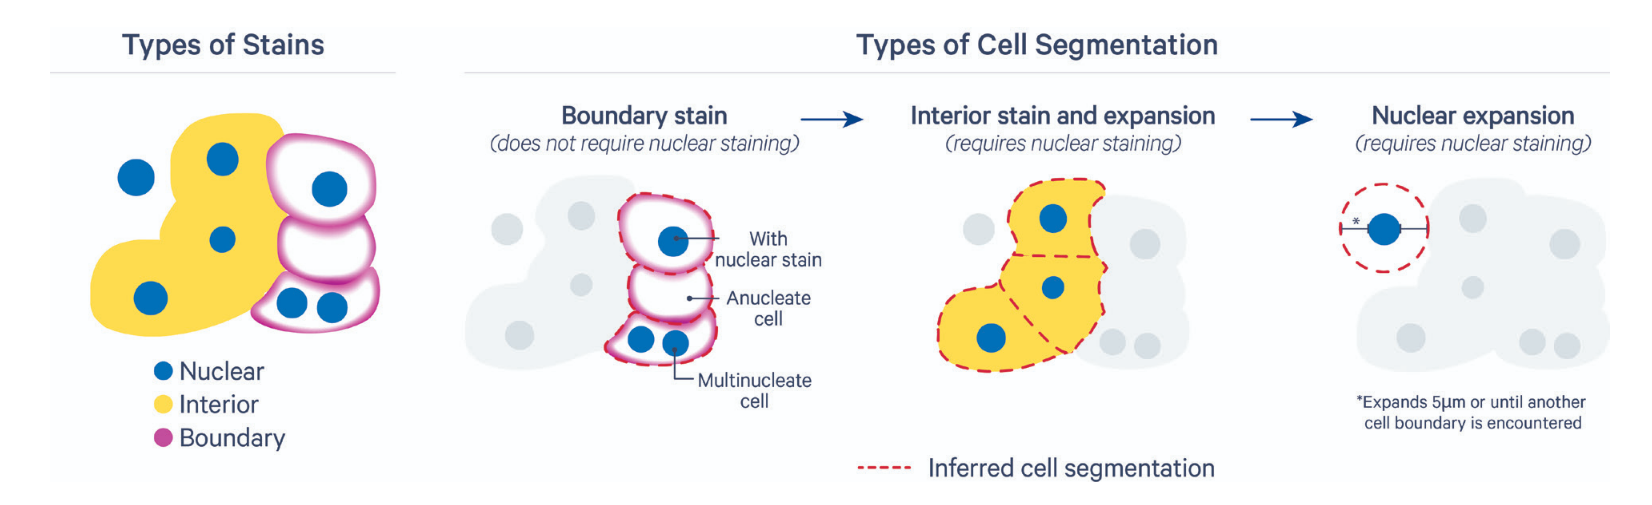

In [ ]:
# Inspect channel names
se = _get_spatial_element(sdata, layer="morphology_focus_global")
channels = se.c.data

print("Channel names:", channels)

In [ ]:
# Plot nucleus segmentation results from Cellpose
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, axes = plt.subplots(4, 1, figsize=(8, 32))
norm = Normalize(vmin=0, vmax=4000)

for ax, channel in zip(axes.ravel(), channels):
    sdata_crop.pl.render_images(
        element="morphology_focus_global", channel=channel, cmap="gray",
    ).pl.render_shapes(
        element="nucleus_shapes_global", fill_alpha=0, outline_width=0.5, outline_alpha=1, outline_color="magenta"
    ).pl.render_shapes(
        element="cell_shapes_global", fill_alpha=0, outline_width=0.5, outline_alpha=1, outline_color="cyan"
    ).pl.show(
        title=channel,
        coordinate_systems="global",
        colorbar=False,
        ax=ax,
    )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.invert_yaxis()

In [ ]:
# Plot segmentation methods from Xenium
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, ax = plt.subplots(figsize=(8, 8))
norm = Normalize(vmin=0, vmax=3000)

sdata_crop.pl.render_images(
    element="morphology_focus_global", channel="DAPI", cmap="gray",
).pl.render_labels(
    element="cell_labels_global", fill_alpha=0.6, contour_px=3, outline_alpha=0, cmap="viridis", color='segmentation_method', table_name="table_global",
).pl.render_shapes(
    element="nucleus_shapes_global", fill_alpha=0, outline_width=0.7, outline_alpha=1, outline_color="magenta"
).pl.render_shapes(
    element="cell_shapes_global", fill_alpha=0, outline_width=0.7, outline_alpha=1, outline_color="cyan"
).pl.show(
    title="Xenium segmentation - Segmention method",
    coordinate_systems="global",
    colorbar=False,
    ax=ax,
)

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

In [ ]:
# Plot number of nuclei from Xenium
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, ax = plt.subplots(figsize=(8, 8))
norm = Normalize(vmin=0, vmax=3000)

sdata_crop.pl.render_images(
    element="morphology_focus_global", channel="DAPI", cmap="gray", colorbar=False,
).pl.render_labels(
    element="cell_labels_global", fill_alpha=0.6, contour_px=3, outline_alpha=0, cmap="viridis", color='nucleus_count', table_name="table_global", colorbar=True
).pl.render_shapes(
    element="nucleus_shapes_global", fill_alpha=0, outline_width=0.7, outline_alpha=1, outline_color="magenta"
).pl.render_shapes(
    element="cell_shapes_global", fill_alpha=0, outline_width=0.7, outline_alpha=1, outline_color="cyan"
).pl.show(
    title="Xenium segmentation - Number of nuclei",
    coordinate_systems="global",
    ax=ax,
)

ax.set_xlim(min_x, max_x)
ax.set_ylim(min_y, max_y)
ax.invert_yaxis()

#### 7.3.2 Cell segmentation using Cellpose 3

In [ ]:
se = _get_spatial_element(sdata, layer="morphology_focus_global")
channels_idx = [
    se.c.data.tolist().index("ATP1A1/CD45/E-Cadherin") + 1, 
    se.c.data.tolist().index("DAPI" ) + 1
] #  + 1 because CellPose channel specifications are 1-indexed!

channels_idx # [membrane stain index + 1, nuclear stain index + 1]

In [ ]:
"""
ADVANCED: You can set up a local Dask distributed cluster for parallel computing. Once the cluster is created, a Dask Client is used to connect to it. 
The Dask dashboard link allows you to monitor cluster performance and task progress.
"""

from dask.distributed import Client, LocalCluster

# # Create a local Dask cluster
cluster = LocalCluster(
     n_workers=8,             # Number of worker processes
     threads_per_worker=1,    # Number of threads per worker
     memory_limit="32GB",     # Memory limit per worker
 )

# # Connect a Client to the cluster
client = Client(cluster)

# # Print the Dask dashboard link
print(client.dashboard_link)

In [ ]:
import torch
from cellpose import models

from harpy.image import cellpose_callable

device = "cpu"  # mps broken in cellpose (macOS), see https://github.com/MouseLand/cellpose/issues/1063

sdata = hp.im.segment(
    sdata,
    img_layer="morphology_focus_global",
    chunks=2048,
    depth=200,
    model=cellpose_callable,
    # parameters that will be passed to the callable _cellpose
    pretrained_model = "cyto3",
    device = device,
    diameter=33,
    flow_threshold=0.9,
    cellprob_threshold=-4,
    channels=channels_idx,
    output_labels_layer="cell_segmentation_mask",
    output_shapes_layer="cell_segmentation_mask_boundaries",
    crd= [10000, 11000, 18000, 19000],  # region to segment [x_min, xmax, y_min, y_max],
    overwrite=True,
)

client.close() # ADVANCED: This closes the Dask Client.

In [ ]:
# Plot nucleus segmentation results from Cellpose vs Xenium
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

shapes_layers = {
    'Cellpose': ['nucleus_segmentation_mask_boundaries', 'cell_segmentation_mask_boundaries'], 
    'Xenium': ['nucleus_shapes_global', 'cell_shapes_global']
}
              
for ax, (method, shapes_layer) in zip(axes, shapes_layers.items()):
    sdata_crop.pl.render_images(
        element="morphology_focus_global", channel=['ATP1A1/CD45/E-Cadherin', '18S', 'AlphaSMA/Vimentin']
    ).pl.render_shapes(
        element=shapes_layer[0], fill_alpha=0, outline_width=0.8, outline_alpha=1, outline_color="magenta"
    ).pl.render_shapes(
        element=shapes_layer[1], fill_alpha=0, outline_width=0.8, outline_alpha=1, outline_color="cyan"
    ).pl.show(
        title=f"Cell segmentation - {method}",
        coordinate_systems="global",
        colorbar=False,
        ax=ax,
    )

    ax.set_xlim(min_x, max_x)
    ax.set_ylim(min_y, max_y)
    ax.invert_yaxis()

## 8. Allocating the transcripts

###  8.1 Creating the count matrix
The transcripts were already read into the SpatialData by the Xenium reader function. For some spatial technologies, it might be necessary to use the general `harpy.io.read_transcripts` function, which you can configure for most types of transcript data. There are also specific reader functions for Resolve Biosciences Molecular Cartography data (`harpy.io.read_resolve_transcripts`) and for Vizgen Merscope data (`harpy.io.read_merscope_transcripts`).

Once the transcripts are read in and we have a segmentation mask, we can allocate the transcripts to the correct cell. This allocation step creates the count matrix saved in an [anndata](https://anndata.readthedocs.io/en/stable/) object.

In [ ]:
# Inspect the points layer
sdata.points["transcripts_global"].head()

In [ ]:
# Allocate transcripts to cells based on the segmentation masks
sdata = hp.tb.allocate(
    sdata=sdata,
    labels_layer="nucleus_segmentation_mask", # The labels layer (i.e. nucleus_segmentation mask) in `sdata` to be used to allocate the transcripts to cells.
    points_layer="transcripts_global", # The points layer in `sdata` that contains the transcripts.
    output_layer="table_transcriptomics", # The table layer in `sdata` in which to save the AnnData object with the transcripts counts per cell.
    update_shapes_layers=False,
    overwrite=True,
)

In [ ]:
# Inspect the new table layer
display(sdata.tables["table_transcriptomics"])

print('Number of cells: ', len(sdata.tables["table_transcriptomics"].obs.index))
print('Number of genes: ', len(sdata.tables["table_transcriptomics"].var.index))

In [ ]:
# Inspect the count matrix in the new table layer
sdata.tables["table_transcriptomics"].to_df().head() # On large count matrices, calls to .to_df() should be avoided

In [ ]:
# Inspect the var of the new table layer
sdata.tables["table_transcriptomics"].var.head()

In [ ]:
# Inspect the obs of the new table layer
sdata.tables["table_transcriptomics"].obs.head()

In [ ]:
# Inspect the spatial coordinates stored in obsm
sdata.tables["table_transcriptomics"].obsm['spatial'][:5] # x,y,(z) coordinates of cell centroid (calculated based on mean transcripts location)

In [ ]:
# Inspect the spatialdata_attrs in .uns to check the instance_key and region_key
sdata.tables["table_transcriptomics"].uns['spatialdata_attrs']

# NOTE: The AnnData object that is added as a table layer is annotated by the labels layer "nucleus_segmentation_mask". The instance_key ('cell_ID') matches the labels in "nucleus_segmentation_mask".
# NOTE: Tables of a SpatialData object can be theoretically be annotated by a labels layer, a shapes layer or a points layer, but tables generated by Harpy will always use a labels layer.

In [ ]:
import dask.array as da

print('Number of cells in table:', len(sdata.tables["table_transcriptomics"].obs))
print('Number of segmentation masks in labels layer:', len(da.unique(sdata.labels["nucleus_segmentation_mask"].data).compute()) - 1) # We subtract 1 because 0 is also a value, but this corresponds to the background.
print('Number of segmentation boundaries in shapes layer:', len(sdata.shapes["nucleus_segmentation_mask_boundaries"]))

# NOTE: Not all segmentation masks are included in the table layer "table_transcriptomics". This is because not all cells could be assigned transcripts.

### 8.2 Visualizing gene expression

In [ ]:
# Plot gene expression for specific gene
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

sdata_crop = sdata.query.bounding_box(
    min_coordinate=[min_x, min_y], 
    max_coordinate=[max_x, max_y], 
    axes=("x", "y"), 
    target_coordinate_system="global"
)

sdata_crop.pl.render_images(
    element="morphology_focus_global", channel="DAPI", cmap="gray", colorbar=False
).pl.render_labels(
    element="nucleus_segmentation_mask", fill_alpha=1, contour_px=3, outline_alpha=0, cmap="viridis", color='HSPD1', table_name="table_transcriptomics"
).pl.show(
    title="Gene expression - HSPD1",
    coordinate_systems="global",
    colorbar=True,
    figsize=(6,6)
)

In [ ]:
# Compare this against the individual transcripts of that gene
hp.pl.plot_sdata_genes(
    sdata,
    img_layer="morphology_focus_global",
    channel="DAPI",
    points_layer="transcripts_global",
    crd=(min_x, max_x, min_y, max_y),
    color="cornflowerblue",
    genes=["HSPD1"],
    frac=1,
    size=1,
    render_images_kwargs={"cmap": "grey"},
    show_kwargs={"title": "Transcripts - HSPD1", "colorbar": False},
    to_coordinate_system="global"
)

In [ ]:
# Explore gene expression interactively using napari-spatialdata

# Interactive(sdata)

<b>Excercise</b>:

Use `napari-spatialdata` to visualize the gene expression of a gene.

###  8.3 Transcript quality
After we have created the anndata object, we want to check the transcript quality. First we create a plot to check if the transcript density is similar across the whole tissue. If this isn't the case, there can be multiple biological or technical reasons. Note that gene panel choices can also have an influence.

In [ ]:
# Create transcript density image
sdata = hp.im.transcript_density(
    sdata,
    img_layer="clahe", # The layer of the SpatialData object used for determining image boundary.
    points_layer="transcripts_global", # The layer name that contains the transcript data points, by default "transcripts".
    output_layer="transcript_density", # The name of the output image layer
    overwrite=True,
)

In [ ]:
# Plot transcript density
sdata.pl.render_images(
    element = "transcript_density",
).pl.show(
    title="Transcript_density",
    coordinate_systems="global",
    colorbar=True,
)

In [ ]:
# Let's compare this against our region annotations for tumor and necrosis
fig, ax = plt.subplots(figsize=(12, 6))

sdata.pl.render_images(
    element = "transcript_density",
).pl.render_shapes(
    element="tumor", color="red", fill_alpha=0, outline_alpha=1, outline_color="red"
).pl.render_shapes(
    element="necrosis", color="black", fill_alpha=0, outline_alpha=1, outline_color="black"
).pl.show(
    title="Transcript_density",
    coordinate_systems="global",
    colorbar=True,
    ax=ax,
)

ax.set_xlim(10000, 20000)
ax.set_ylim(18000, 28000)
ax.invert_yaxis()

In [ ]:
# NOTE for Arne: The plot_density function above is just a proof-of-concept I threw together for the training. 
# It's not battletested yet, but I do think there is value in including this in Harpy.

In [ ]:
# We created a quick function for the training to easily plot cell density
from _plot_density import plot_density

plot_density(
    sdata=sdata, 
    table_layer="table_transcriptomics",
    bin_size=30,
    smooth_sigma=0.7,
    crd = None
)

In [ ]:
# We can also plot the transcript density for all genes, a single gene or a list of genes.
plot_density(
    sdata=sdata, 
    points_layer="transcripts_global",
    genes="HSPD1", 
    bin_size=40,
    smooth_sigma=0.6, # Slight smoothing to improve the look of the plot
    crd = None
)

In [ ]:
# Check number of transcripts
print('Number of transcripts in points layer: ', len(sdata.points["transcripts_global"]))
print('Number of transcripts assigned to cells: ', sdata.tables["table_transcriptomics"].X.sum())
print('Percentage of transcripts kept: ', ((sdata.tables["table_transcriptomics"].X.sum())/len(sdata.points["transcripts_global"]))*100)

# NOTE: Only a fraction of transcripts are assigned to cells.

In [ ]:
# Check number of genes
print('Number of genes in points layer: ', sdata.points['transcripts_global'].compute()['gene'].nunique())
print('Number of genes found in cells: ', len(sdata.tables["table_transcriptomics"].var.index))

# NOTE: In general, we don't want to lose any genes, but this may happen if they have a low abundance.

In [ ]:
# Check which genes are not found in cells
genes_not_found_in_cells = set(sdata.points['transcripts_global'].compute()['gene'].unique()) - set(sdata.tables["table_transcriptomics"].var.index)

print("Number of genes not found in cells: ", len(genes_not_found_in_cells))
print("Genes not found in cells:", genes_not_found_in_cells)


In [ ]:
# Convert the transcript points table to a DataFrame
df_transcripts = sdata.points["transcripts_global"].compute()

# Filter and count transcripts for Ms4a7
gene_name = "Human_PTEN_G129E_WT:A"
count = (df_transcripts["gene"] == gene_name).sum()

print(f"Number of transcripts for {gene_name}: {count}")

In [ ]:
# Analyse and visualize the proportion of transcripts that could not be assigned to a cell during allocation step.
df_analyse_genes_left_out = hp.pl.analyse_genes_left_out(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    table_layer="table_transcriptomics",
    points_layer="transcripts_global",
)

# NOTE: In general we see a downward trend. The more a gene is measured, the less it is located in cells (in ratio). 
# NOTE: The function also prints the ten genes with the highest proportion of transcripts filtered out. If a lot of these genes are markers for the same cell type, you will want to find out why this is happening (bad staining, large cell body compared to nucleus, etc.)

In [ ]:
# Inspect analyse_genes_left_out() output table
df_analyse_genes_left_out.sort_values(by="proportion_kept", ascending=True)

### 8.4 Comparing Xenium and SPArrOW allocation
Xenium already allocated transcripts to their segmentation masks and this data was read in using the Xenium reader. In principle, we would not need to repeat this step. However, below, we will redo the allocation and compare the results to the Xenium allocation. We generally would recommend to redo the allocation for Xenium using SPArrOW's algorithm.

In [ ]:
sdata = hp.tb.allocate(
    sdata=sdata,
    labels_layer="cell_labels_global", # we use the segmentation mask from Xenium
    points_layer="transcripts_global",
    output_layer="table_global_sparrow",
    update_shapes_layers=False,
    overwrite=True,
)

In [ ]:
# AnnData table from Xenium transcript allocation
sdata.tables["table_global"]

In [ ]:
# AnnData table from SPArOW transcript allocation
sdata.tables["table_global_sparrow"]

In [ ]:
# Obs layer from Xenium transcript allocation
sdata.tables["table_global"].obs.head()

In [ ]:
# Obs layer from SPArOW transcript allocation
sdata["table_global_sparrow"].obs.head()

In [ ]:
# Compare the number of transcripts allocated to the cell with ID 27401, in the allocation done by Xenium versus the one done by SPArrOW
cell_ID = 27401

idx_xenium = sdata.tables["table_global"].obs.index[sdata.tables["table_global"].obs["cell_ID"] == cell_ID][0]
idx_sparrow = sdata.tables["table_global_sparrow"].obs.index[sdata.tables["table_global_sparrow"].obs["cell_ID"] == cell_ID][0]

print("Xenium:", sdata.tables["table_global"][idx_xenium].X.sum(), "transcripts")
print("SPArrOW:", sdata.tables["table_global_sparrow"][idx_sparrow].X.sum(), "transcripts")

# NOTE: We get less transcripts for Xenium's allocation than for SPArrOW's allocation. 

In [ ]:
# Show the counts for genes assigned to cell with ID 27401 by SPArrOW
sdata.tables["table_global_sparrow"][idx_sparrow].to_df().T.sort_values(by=idx_sparrow, ascending=False).head(n=10)

In [ ]:
# # Show the counts for genes assigned to cell with ID 27401 by Xenium
sdata.tables["table_global"][idx_xenium].to_df().T.sort_values(by=idx_xenium, ascending=False).head(n=10)

In [ ]:
# We can extract the obs information for a specific cell of interest like this:
sdata["table_global_sparrow"][idx_sparrow].obs

In [ ]:
# And we can get the cell's (x,y) location in image coordinates
coords = sdata["table_global_sparrow"][idx_sparrow].obsm["spatial"][0]
x = int(coords[0])
y = int(coords[1])

print(f"Cell with ID {cell_ID} is located at coordinates: ({x}, {y})")

In [ ]:
# Plot a close-up of the cell with ID 27401, and the transcripts for gene HSPD1 to confirm that there are indeed 9 transcripts inside the cell
hp.pl.sanity(
    sdata,
    img_layer="morphology_focus_global",
    shapes_layer="cell_shapes_global",
    points_layer="transcripts_global",
    plot_cell_number=True,
    gene="HSPD1",
    crd=[x-60, x+60, y-60, y+60],
    figsize=(5,5),
)

In [ ]:
# Let's clean up the table layer since we don't need it anymore
del sdata.tables["table_global_sparrow"]
sdata.delete_element_from_disk("table_global_sparrow")

## 9. Processing the AnnData table

### 9.1 Filtering and Normalization

The next steps are performed to further process the AnnData object:

- QC metrics are calculated.
- Filtering: cells with fewer than a certain amount of counts (e.g. 10) and genes occuring in fewer than a certain amount of cells (e.g. 5) are filtered out.
- Normalization: for small gene panels (<500), we recommend to normalize the data based on the size of the segmented object (`size_norm=True`). For transcriptome-wide methods, we recommend library size normalization based on the total expression (`size_norm=False`). 
- log1p-transformation of the expression data (y=ln(1+x)).
- Scale data to unit variance and zero mean. The scaling is capped at `max_value_scale`.
- PCA calculation

In [ ]:
# Perform preprocessing.
sdata = hp.tb.preprocess_transcriptomics(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    table_layer="table_transcriptomics",
    output_layer="table_transcriptomics_preprocessed", # write results to a new slot, we could also write to the same slot (when passing overwrite==True).
    min_counts=10,
    min_cells=5,
    size_norm=False,
    highly_variable_genes=False,  # If True, will only retain highly variable genes. This can be used for transcriptome-wide methods.
    max_value_scale=10, # The maximum value to which data will be scaled
    n_comps=50, # Number of principal components to calculate.
    overwrite=True,
    update_shapes_layers=False,
)

In [ ]:
# Inspect preprocessed table
sdata.tables["table_transcriptomics_preprocessed"]

In [ ]:
# Inspect expression values
sdata.tables["table_transcriptomics_preprocessed"].to_df().head()

In [ ]:
# Check mean expression values per gene
sdata.tables["table_transcriptomics_preprocessed"].to_df().mean(axis=0).head() # mean ~ 0

In [ ]:
# Check standard deviation of expression values per gene
sdata.tables["table_transcriptomics_preprocessed"].to_df().std(axis=0).head() # std ~ 1

In [ ]:
# Check max expression value per gene
sdata.tables["table_transcriptomics_preprocessed"].to_df().max(axis=0).head() # max ~ 10

In [ ]:
# Inspect obs of preprocessed table
sdata.tables["table_transcriptomics_preprocessed"].obs.head()

# n_genes_by_counts: The number of genes with at least 1 count in a cell
# log1p_n_genes_by_counts: log1p-transformed n_genes_by_counts
# total_counts: Total number of counts for a cell
# log1p_total_counts: log1p-transformed total_counts
# pct_counts_in_top_2_genes: The percentage of the total gene expression in each cell that comes from the top 2 most highly expressed genes in that cell
# pct_counts_in_top_5_genes: The percentage of the total gene expression in each cell that comes from the top 5 most highly expressed genes in that cell 
# n_counts: Number of counts in a cell
# shapeSize: Area of cell (in pixels)

In [ ]:
# Inspect var of preprocessed table
sdata.tables["table_transcriptomics_preprocessed"].var.head()

# n_cells_by_counts: Number of cells this gene is found in
# mean_counts: Mean counts over all cells
# log1p_mean_counts: log1p of mean_counts
# pct_drop_by_counts: Percentage of cells this gene does not appear in
# total_counts: Total number of counts for a gene
# logp_total_counts: log1p of total_counts
# n_cells: Number of cells this gene is found in
# mean:
# std:

In [ ]:
# Plot preprocessing QC plots
hp.pl.preprocess_transcriptomics(
    sdata,
    table_layer="table_transcriptomics_preprocessed",
)

In [ ]:
# Plot total counts spatially
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="total_counts",
    crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey", "colorbar": False},
    render_labels_kwargs={"fill_alpha": 0.7, "colorbar": True},
    show_kwargs={"title": "Total counts"},
)

In [ ]:
# Plot a histogram of segmentation mask areas
ax = sdata.tables["table_transcriptomics_preprocessed"].obs['shapeSize'].plot.hist(
    bins=50,
    figsize=(6,4),
    edgecolor='white',
    color='steelblue'
)

ax.set_xlabel("shapeSize (pixels)")
ax.set_ylabel("Number of cells")
ax.set_title("Area of Segmentation Masks")
plt.tight_layout()

In [ ]:
sdata.tables["table_transcriptomics_preprocessed"].obs['shapeSize'].describe()

In [ ]:
# Plot segmentation mask areas spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="shapeSize",
    crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey", "colorbar": False},
    render_labels_kwargs={"fill_alpha": 0.7, "colorbar": True},
    show_kwargs={"title": "Segmentation mask areas"},
)

In [ ]:
# Filter cells on size
sdata = hp.tb.filter_on_size(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    table_layer="table_transcriptomics_preprocessed",
    output_layer="table_transcriptomics_preprocessed",
    min_size=500, # Minimum cell size
    max_size=4200, # Maximum cell size
    update_shapes_layers=False, # Be careful with setting this to True, it might filter cells from shapes layers that you don't want to filter !
    overwrite=True,
)

In [ ]:
# NOTE for Arne: For the summer school, I think we'll also need to show how to filter anndata tables based on any numerical or categorical value for both the obs and var.
# See the region annotations PR.

In [ ]:
# NOTE for Arne: If I use 'update_shapes_layers' here, I lose cells from 'cell_shapes_global', which I don't want to filter so I can't use it here. For the summer school, it would be nice to be able to plot which cells were filtered out.


In [ ]:
# Plot segmentation mask areas spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="shapeSize",
    crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey", "colorbar": False},
    render_labels_kwargs={"fill_alpha": 0.7, "colorbar": True},
    show_kwargs={"title": "Segmentation mask areas"},
)

### 9.2 Clustering

This function performs the neighborhood analysis and the leiden clustering and the UMAP calculations using standard scanpy functions.

You need to define the following parameters:
- The amount of PC's used: Between 15-20 is a good starting point (based on the plot of PCs).
- The amount of neighbors used: 35 is generally a good value. In general, less neighbors means more spread, more means everything is tighter.
- Cluster resolution.

It returns the UMAP and marker gene list per cluster, that can be looked at for finding celltypes. 

In [ ]:
# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    table_layer="table_transcriptomics_preprocessed",
    output_layer="table_transcriptomics_preprocessed",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17, # The number of principal components to use when calculating neighbors.
    n_neighbors=35, # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(sdata.tables["table_transcriptomics_preprocessed"], color=["leiden"], show=True)

In [ ]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="leiden",
    # crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

In [ ]:
# We can plot other variables on the UMAP as well
from matplotlib.pyplot import rc_context
color_vars = [
    "n_counts",
    "n_genes_by_counts",
    "shapeSize",
    "TPX2",
    "leiden",
]
with rc_context({"figure.figsize": (3, 3)}):
    sc.pl.umap(sdata.tables["table_transcriptomics_preprocessed"], color=color_vars, ncols=3)

In [ ]:
sc.pl.rank_genes_groups(sdata.tables["table_transcriptomics_preprocessed"], n_genes=8, sharey=False, show=True)

### 9.3 Cell type annotation
Cell type annotation is fairly complex and requires a lot of biological insights to do correctly. We will show some approaches here, but others exist as well.

10X Genomics has a good [analysis guide](https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation) on how they annotated the cell types in this dataset using label transfer from an accompanying scRNAseq reference dataset.

We have also explored and recreated 10X genomics' annotation for the full dataset using Harpy. You can find the tutorial [here](https://harpy.readthedocs.io/en/latest/tutorials/advanced/Harpy_transcriptomics_xenium.html).

#### 9.3.1 Annotating clusters

In [ ]:
# First, we specify a dictionary with marker genes for the different cell types of interest.
marker_genes_dict = {
    'Urothelial-like Cells': ['SLC40A1', 'TRIM29', 'DSC3', 'TNS4', 'PLAT', 'ANXA8', 'AVPI1', 'FGFR3'],
    'Proliferative Tumor Cells': ['SMC4', 'UCHL1', 'TPX2', 'BIRC5', 'TOP2A', 'STMN1', 'MYBL2', 'CENPF', 'CDK1', 'TYMS'],
    'Tumor Cells': ['PLXNB1', 'CP', 'NORAD', 'PRKCI', 'MUC16', 'RGL3'],
    'Tumor Associated Fibroblasts': ['LUM', 'BGN', 'COL5A1', 'MMP14', 'CTHRC1', 'COL5A2', 'CCN2', 'COL11A1', 'THBS2', 'LOXL1', 'CDH11', 'PLAU', 'INHBA', 'SERPINE1', 'ADAMTS14', 'LOX'],
    'Smooth Muscle Cells': ['MYH11', 'C11orf96', 'CNN1'],
    'Macrophages': ['C1QC', 'MS4A6A', 'AIF1', 'FCGR2A', 'ITGB2', 'CD14', 'MSR1'],
    'SOX2-OTpos Tumor Cells': ['NAMPT', 'SOST', 'SOX2-OT'],
    'Stromal Associated Fibroblasts': ['C7', 'ABCA10'],
    'Stromal Associated Endothelial Cells': ['AQP1', 'EPAS1'],
    'T and NK Cells': ['TRAC', 'CD52', 'CD8A', 'TRBC1'],
    'Pericytes': ['COL4A1', 'HEYL', 'PDGFRB', 'ENPEP', 'AVPR1A', 'RGS5', 'PDGFA'],
    'Tumor Associated Endothelial Cells': ['FLT1', 'PLVAP', 'PTPRB', 'ESM1', 'CD93', 'PECAM1', 'NOTCH4', 'EGFL7', 'CLEC14A'],
    'VEGFApos Tumor Cells': ['TFPI2', 'NDRG1', 'SLC2A1', 'VEGFA', 'AMOTL2', 'P4HA1', 'ALDOA', 'ANKRD33B'],
    'Fallopian Tube Epithelium': ['AC007906.2', 'KCNC3', 'PFKFB3'],
    'Malignant Cells Lining Cyst': ['CLDN1', 'C4B', 'PROCR', 'C4A', 'DSC3', 'PRG4', 'RGS4', 'CALB2', 'BNC1', 'CPA4'],
    'Inflammatory Tumor Cells': ['MX1', 'STAT1', 'IFI44L', 'SAMD9', 'IFIT1', 'PLSCR1', 'IFIT3', 'GBP1', 'DDX58', 'OAS3', 'RSAD2', 'CXCL10', 'IFIT2', 'IFI35', 'PNPT1', 'IFIH1', 'OAS1', 'TNFSF10'],
    'Ciliated Epithelial Cells': ['C20orf85', 'CFAP100', 'FAM183A', 'TEKT1', 'TPPP3', 'ERICH3', 'CDHR4', 'FAM216B', 'IL5RA', 'CFAP47', 'LDLRAD1'],
}

In [ ]:
# We can visualize the expression of these marker genes in the Leiden clusters using a scanpy's matrix plot.
sc.pl.matrixplot(
    sdata.tables["table_transcriptomics_preprocessed"], 
    var_names=marker_genes_dict, 
    groupby="leiden", 
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
    figsize=(32, 6)
)

In [ ]:
# We can also use a dot plot
sc.pl.dotplot(
    sdata.tables["table_transcriptomics_preprocessed"], 
    var_names=marker_genes_dict, 
    groupby="leiden", 
    cmap="Blues",
    figsize=(32, 6)
)

In [ ]:
# The heatmap plot does not collapse the cells into a single average value per cluster
sc.pl.heatmap(
    sdata.tables["table_transcriptomics_preprocessed"], 
    var_names=marker_genes_dict, 
    groupby="leiden", 
    cmap="viridis", 
    figsize=(32, 6)
)

# For more visualization options, see the scanpy documentation: https://scanpy.readthedocs.io/en/stable/tutorials/plotting/core.html

#### 9.3.2 Annotating cells using sc.tl.score_genes

We can also use a marker gene list and score cells for each cell type using those markers via scanpy's `sc.tl.score_genes` function.

In [ ]:
all_genes = sorted(set(gene for genes in marker_genes_dict.values() for gene in genes))

# Create one-hot matrix
df = pd.DataFrame(0, index=all_genes, columns=marker_genes_dict.keys())

for cell_type, genes in marker_genes_dict.items():
    df.loc[genes, cell_type] = 1
    
df.columns = df.columns.str.replace(' ', '_', regex=False) # whitespaces no longer allowed since spatialdata>=0.3.0
df

In [ ]:
# Annotate cells
sdata, celltypes_scored, celltypes_all = hp.tb.score_genes(
    sdata,
    labels_layer="nucleus_segmentation_mask",
    table_layer="table_transcriptomics_preprocessed",
    output_layer="table_transcriptomics_preprocessed",
    marker_genes=df, # marker_genes can also be a path to a CSV-file
    overwrite=True,
)

In [ ]:
# Inspect new table layer
sdata["table_transcriptomics_preprocessed"]

In [ ]:
# Inspect new table layer obs
sdata.tables["table_transcriptomics_preprocessed"].obs.head()

In [ ]:
# Plot cell type annotations on UMAP
sc.pl.umap(sdata.tables["table_transcriptomics_preprocessed"], color="annotation")

In [ ]:
# Plot cell type annotations spatially
min_x = 10000
max_x = 11000
min_y = 18000
max_y = 19000

hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="annotation",
    # crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Annotation", "colorbar": False},
)

In [ ]:
# Let's inspect the cell type counts and percentages
counts = sdata.tables["table_transcriptomics_preprocessed"].obs['annotation'].value_counts()
percentages = sdata.tables["table_transcriptomics_preprocessed"].obs['annotation'].value_counts(normalize=True) * 100

cluster_summary = pd.DataFrame({
    'count': counts,
    'percentage': percentages.round(2)
})

print(cluster_summary)

### 9.4 Using region annotations
We can use region annotations to assign which cells occurs within or outside those regions, calculate distances to the edge of the annotation, filter cells based on their relation the region annotation, etc.

Note that one should be very careful here to consider all coordinate spaces and transformations involved to make sure the results are correct.

In [ ]:
from shapely.geometry import Point

# Get spatial coordinates
spatial_coords = sdata.tables['table_transcriptomics_preprocessed'].obsm["spatial"]
spatial_coords_df = pd.DataFrame(spatial_coords, columns=["x", "y"], index=sdata.tables['table_transcriptomics_preprocessed'].obs.index)

# Define function to assign region annotations to cells
def assign_region(centroid, gdf):
    for index, row in gdf.iterrows():
        if Point(centroid).within(row["geometry"]):
            return "Yes"
    return "No"  

# Create new column in obs to check if cells are in region
sdata.tables['table_transcriptomics_preprocessed'].obs["in_tumor"] = spatial_coords_df.apply(lambda row: assign_region((row["x"], row["y"]), sdata.shapes["tumor"]), axis=1)

# Add table layer to back to zarr
from harpy.utils._keys import _REGION_KEY
region = sdata["table_transcriptomics_preprocessed"].obs[_REGION_KEY].cat.categories.to_list()

sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_preprocessed"],
    output_layer="table_transcriptomics_preprocessed",
    region=region,
    overwrite=True,
)

In [ ]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color="in_tumor",
    # crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

In [ ]:
# We can now check where the annotated cells are located in the UMAP
sc.pl.umap(sdata.tables["table_transcriptomics_preprocessed"], color=["in_tumor"], show=True)

### 9.5 Squidpy

#### 9.5.1 Constructing spatial graphs
The spatial graph is a network where each node represents an observation (spot/cell) and edges signify neighborhood relationships (calculated based on the spatial coordiantes of the observations). This graph is useful for various analyses, such as neighborhood enrichment and calcualting spatial statistics such as spatial autocorrelation.

We use squidpy.gr.spatial_neighbors to compute the spatial neighbors graph in this non-grid dataset, setting coord_type="generic", and n_neighs=6 to specify that each observation should have 6 neighbors (this is called K-nearest neighbors(KNN)). We could also calculate neighbor relationships based on a radius around each cell or we could set delaunay=True to apply Delaunay triangulation.

In [ ]:
# Try calculating spatial neighbors using Squidpy
sq.gr.spatial_neighbors(
    adata=sdata["table_transcriptomics_preprocessed"], 
    coord_type="generic", # Set to 'generic' for targeted spatial transcriptomics
    n_neighs=6, # Only used when delaunay = False
    radius=None, # To compute the neighbors based on the radius
    delaunay=False, # Whether to compute the graph from Delaunay triangulation
    set_diag=False, # Whether to set the diagonal of the connectivity matrix to 1 (i.e. whether cells should be considered neighbors of themselves).
    key_added="KNN"
)

sdata.tables["table_transcriptomics_preprocessed"]

In [ ]:
# BUT, this is not yet backed to the zarr store!
from spatialdata import read_zarr

sdata = read_zarr(sdata.path)

sdata.tables["table_transcriptomics_preprocessed"]

# NOTE: .uns["spatial_neighbors"], .obsp["spatial_connectivities"] and .obsp["spatial_distances"] are no longer in table!

In [ ]:
# Let's try calculating the spatial neighbors again, but we'll make sure the new table is backed to the zarr store by using hp.tb.add_table_layer().
from harpy.utils._keys import _REGION_KEY

sq.gr.spatial_neighbors(
    adata=sdata["table_transcriptomics_preprocessed"], 
    coord_type="generic", # Set to 'generic' for targeted spatial transcriptomics
    n_neighs=6, # Only used when delaunay = False
    radius=None, # To compute the neighbors based on the radius
    delaunay=False, # Whether to compute the graph from Delaunay triangulation
    set_diag=False, # Whether to set the diagonal of the connectivity matrix to 1 (i.e. whether cells should be considered neighbors of themselves).
    key_added="KNN"
)

region = sdata["table_transcriptomics_preprocessed"].obs[_REGION_KEY].cat.categories.to_list()

sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_preprocessed"],
    output_layer="table_transcriptomics_squidpy",
    region=region, # A list of regions to associate with the table data. Typically this is all unique elements in adata.obs[_REGION_KEY].
    overwrite=True,
)

In [ ]:
# Inspect spatial connectivities of first 5 rows and colomns
sdata.tables['table_transcriptomics_squidpy'].obsp['KNN_connectivities'].toarray()[0:5,0:5]

In [ ]:
# Inspect spatial distances
sdata.tables['table_transcriptomics_squidpy'].obsp['KNN_distances'].toarray()[0:5,0:5]

In [ ]:
# Inspect number of neighbors (for first 5cells)
sdata.tables['table_transcriptomics_squidpy'].obsp['KNN_connectivities'].toarray().sum(axis=1)[0:5] # sums across the columns for each row

# NOTE: Every cell has exactly 6 neighbors when using n_neigh=6

In [ ]:
# Inspect for every cell how many cells have it as a neighbor (for first 5 cells)
sdata.tables['table_transcriptomics_squidpy'].obsp['KNN_connectivities'].toarray().sum(axis=0)[0:5] # sums across the rows for each column

# NOTE: Not every cell is a neighbor of exactly 6 cells when using n_neigh=6

In [ ]:
sq.pl.spatial_scatter(
    sdata.tables["table_transcriptomics_squidpy"],
    shape=None,
    color="annotation",
    connectivity_key="KNN_connectivities",
    size=10,
    figsize=(10,10),
    legend_loc='best',
    legend_fontsize=7,
    dpi=300
)

<b>Excercise</b>:

- Build a graph of spatial neighbors using a radius (e.g. 150 pixels) and plot the results using 'sq.pl.spatial_scatter'. Inspect the neighbor relationships in both directions for the first 5 cells. How does this compare to the results for 6-nearest neighbors spatial graph? Do the same for Delaunay triangulation.

<details>
<summary>Click to reveal the solution</summary>

```python
# radius-based spatial graphs
from harpy.utils._keys import _REGION_KEY

sq.gr.spatial_neighbors(
    adata=sdata["table_transcriptomics_preprocessed"], 
    coord_type="generic", # Set to 'generic' for targeted spatial transcriptomics
    n_neighs=6, # Only used when delaunay = False
    radius=150, # To compute the neighbors based on the radius
    delaunay=False, # Whether to compute the graph from Delaunay triangulation
    set_diag=False, # Whether to set the diagonal of the connectivity matrix to 1 (i.e. whether cells should be considered neighbors of themselves).
    key_added="radius"
)

region = sdata["table_transcriptomics_preprocessed"].obs[_REGION_KEY].cat.categories.to_list()

sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_preprocessed"],
    output_layer="table_transcriptomics_squidpy",
    region=region, # A list of regions to associate with the table data. Typically this is all unique elements in adata.obs[_REGION_KEY].
    overwrite=True,
)

print('Inspect number of neighbors (for first 5 cells):')
display(sdata.tables['table_transcriptomics_squidpy'].obsp['radius_connectivities'].toarray().sum(axis=1)[0:5])

print('Inspect for every cell how many cells have it as a neighbor (for first 5 cells):')
display(sdata.tables['table_transcriptomics_squidpy'].obsp['radius_connectivities'].toarray().sum(axis=0)[0:5])

sq.pl.spatial_scatter(
    sdata.tables["table_transcriptomics_squidpy"],
    shape=None,
    color="annotation",
    connectivity_key="radius_connectivities",
    size=10,
    figsize=(10,10),
    legend_loc='best',
    legend_fontsize=7,
    dpi=300
)

# Delaunay triangulation
from harpy.utils._keys import _REGION_KEY

sq.gr.spatial_neighbors(
    adata=sdata["table_transcriptomics_preprocessed"], 
    coord_type="generic", # Set to 'generic' for targeted spatial transcriptomics
    n_neighs=6, # Only used when delaunay = False
    radius=None, # To compute the neighbors based on the radius
    delaunay=True, # Whether to compute the graph from Delaunay triangulation
    set_diag=False, # Whether to set the diagonal of the connectivity matrix to 1 (i.e. whether cells should be considered neighbors of themselves).
    key_added="delaunay"
)

region = sdata["table_transcriptomics_preprocessed"].obs[_REGION_KEY].cat.categories.to_list()

sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_preprocessed"],
    output_layer="table_transcriptomics_squidpy",
    region=region, # A list of regions to associate with the table data. Typically this is all unique elements in adata.obs[_REGION_KEY].
    overwrite=True,
)

print('Inspect number of neighbors (for first 5 cells):')
display(sdata.tables['table_transcriptomics_squidpy'].obsp['delaunay_connectivities'].toarray().sum(axis=1)[0:5])

print('Inspect for every cell how many cells have it as a neighbor (for first 5 cells):')
display(sdata.tables['table_transcriptomics_squidpy'].obsp['delaunay_connectivities'].toarray().sum(axis=0)[0:5])

sq.pl.spatial_scatter(
    sdata.tables["table_transcriptomics_squidpy"],
    shape=None,
    color="annotation",
    connectivity_key="delaunay_connectivities",
    size=10,
    figsize=(10,10),
    legend_loc='best',
    legend_fontsize=7,
    dpi=300
)

#### 9.5.2 Neighborhood enrichment analysis
Then we can calculate the neighborhood enrichment score with squidpy.gr.nhood_enrichment. This function will generate a dictionary stored in adata.uns['annotated_nhood_enrichment'] that will contain a z scores matrix and and a count matrix.

The count matrix represents how often each pair of cell types are neighbors in the dataset. Each row in this count matrix represents a cell type, and each column shows how many times it’s connected to other cell types.

For each pair of cell types, the observed counts from the original data are compared to, for example, 1000 permutations (depending on the n_perms argument) and a z-score is calculated. The z-score is a measure of how many standard deviations the observed count deviates from the distribution generated by random permutations.

In [ ]:
# Calculate neighborhood enrichment
sq.gr.nhood_enrichment(
    sdata.tables["table_transcriptomics_squidpy"], 
    cluster_key='annotation', 
    connectivity_key='KNN'
)

# Add table layer to back to zarr
sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_squidpy"],
    output_layer="table_transcriptomics_squidpy",
    region=region,
    overwrite=True,
)

# NOTE: Also see harpy.tb.nhood_enrichment and harpy.pl.nhood_enrichment

In [ ]:
# Plot neighborhood enrichment
sq.pl.nhood_enrichment(
    sdata.tables["table_transcriptomics_squidpy"],
    cluster_key='annotation', 
    mode='zscore',
)

#### 9.5.3 Spatial autocorrelation
Moran’s I can be understood as the Pearson correlation between the value at each location and the average value at its neighbors. Just like Pearson correlation, Moran’s I is bound between -1 and 1, where positive value indicates positive spatial autocorrelation and negative value indicates negative spatial autocorrelation.

In [ ]:
# Calculate Moran’s I global spatial auto-correlation statistics
sq.gr.spatial_autocorr(
    adata=sdata.tables["table_transcriptomics_squidpy"],
    mode="moran",
    n_perms=10, # We set this to 10 to speed up the calculations for the training. When working with actual data, n_perms=100 is probably more appropriate.
    n_jobs=1,
    connectivity_key='KNN_connectivities'
)

# Add table layer to back to zarr
sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_squidpy"],
    output_layer="table_transcriptomics_squidpy",
    region=region,
    overwrite=True,
)

In [ ]:
# Inspect highest Moran's I scores
sdata.tables["table_transcriptomics_squidpy"].uns["moranI"].head(10)

In [ ]:
# Inspect lowest Moran's I scores
sdata.tables["table_transcriptomics_squidpy"].uns["moranI"].tail(10)

In [ ]:
# Let's inspect the spatial expression pattersn for the 9 highest Moran's I scores.
color_vars = sdata.tables["table_transcriptomics_squidpy"].uns["moranI"].index[0:9]

with rc_context({"figure.figsize": (4, 5)}):
    sq.pl.spatial_scatter(
        sdata.tables["table_transcriptomics_squidpy"],
        shape=None,
        color=color_vars,
        size=5,
        ncols=3,
        dpi=300
    )


In [ ]:
# UMAPs of 9 highest Moran's I scores
with rc_context({"figure.figsize": (4, 4)}):
    sc.pl.umap(
        sdata.tables["table_transcriptomics_squidpy"], 
        color=color_vars, 
        ncols=3,
    )

### 9.6 Neighborhood clustering

In [ ]:
from _nhood_clustering import nhood_count, nhood_kmeans

# First, we create a spatial graph. Using a radius-based graph is the most intuitive here.
r = 100
sq.gr.spatial_neighbors(
    adata=sdata.tables["table_transcriptomics_preprocessed"], 
    coord_type="generic",
    radius=r,
    key_added=f"radius_{r}"
)

# Next, we calculate the neighborhood composition around each cell
sdata = nhood_count(
    sdata, 
    table_layer="table_transcriptomics_preprocessed",
    output_layer="table_transcriptomics_preprocessed",
    cell_type_column="annotation",
    connectivity_key=f'radius_{r}_connectivities',
    save_key=f'radius_{r}_nhood_counts',
    overwrite=True,
)

In [ ]:
# Then, we perform kmeans clustering to determine neighborhoods
k = 6
sdata = nhood_kmeans(
    sdata,
    table_layer="table_transcriptomics_preprocessed",
    output_layer="table_transcriptomics_preprocessed",
    nhood_counts_key=f'radius_{r}_nhood_counts',
    output_column=f'nhood_kmeans_r{r}_k{k}',
    n_clusters=k,
    random_state=100,
    nan_label=None,
    overwrite=True,
)

In [ ]:
# NOTE for Arne: I pretty sure the nhood_kmeans() is actually not efficient enough for the students to run locally. If not, we may just want to show the results on the full dataset and skip this step during the training.
#   I just thought it would be nice to show since we used show this using scimap in the previous trainings

In [ ]:
# Plot K-means clustering spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_preprocessed",
    labels_layer="nucleus_segmentation_mask",
    color=f'nhood_kmeans_r{r}_k{k}',
    # crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Neighborhood clusters", "colorbar": False},
)

In [ ]:
# Plot cell type composition of neighborhoods
pivot_df = sdata.tables['table'].obs.pivot_table(index=f'nhood_kmeans_r{r}_k{k}', columns="annotation", aggfunc='size', fill_value=0)
proportions = pivot_df.div(pivot_df.sum(axis=1), axis=0)
proportions = proportions.reset_index()

ax = proportions.plot.bar(x=f'nhood_kmeans_r{r}_k{k}', stacked=True, cmap = "rainbow", figsize=(6, 6), width = 0.9, edgecolor = "black", linewidth = 0.5)

fig = ax.get_figure()

ax.set_xlabel(f'nhood_kmeans_r{r}_k{k}', fontsize=14, color="black")
ax.set_ylabel("Proportion", fontsize=14, color="black")
ax.tick_params(axis="x", rotation=20, colors="black")
ax.tick_params(axis="y", colors="black")

handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1],
    labels[::-1],
    title=f'nhood_kmeans_r{r}_k{k}',
    bbox_to_anchor=(1, 1.02),
    fontsize=12,
    labelcolor="black",
    frameon=False,
)


## 10. Segmentation-free analysis

In [ ]:
# First, we create new labels and shapes layers for a hexagonal grid 
from harpy.image._image import _get_spatial_element
from spatialdata.transformations import get_transformation

se = _get_spatial_element(sdata, layer="morphology_focus_global")
shape = (se.shape[2], se.shape[1])

transformations = get_transformation(sdata.images["morphology_focus_global"], get_all=True)

size = 50 # radius of the hexagon, or size length of the square.

sdata = hp.im.add_grid_labels_layer(
    sdata, 
    shape=shape, # shape of the resulting labels layer, shape y, x
    size=size, 
    output_shapes_layer=f"shapes_spots_{size}um", 
    output_labels_layer=f"labels_spots_{size}um", 
    grid_type='hexagon', # Set to 'square' for square grid
    offset=(0, 0), 
    chunks=1024, 
    client=None, 
    transformations=transformations, 
    scale_factors=(2, 2, 2, 2),
    overwrite=True
)

In [ ]:
# Allocate transcripts
sdata = hp.tb.allocate(
    sdata=sdata,
    labels_layer=f"labels_spots_{size}um",
    points_layer="transcripts_global", # The points layer in `sdata` that contains the transcripts.
    output_layer="table_transcriptomics_hex", # The table layer in `sdata` in which to save the AnnData object with the transcripts counts per cell.
    update_shapes_layers=False,
    overwrite=True,
)

# Perform preprocessing.
sdata = hp.tb.preprocess_transcriptomics(
    sdata,
    labels_layer=f"labels_spots_{size}um",
    table_layer="table_transcriptomics_hex",
    output_layer="table_transcriptomics_hex_preprocessed", # write results to a new slot, we could also write to the same slot (when passing overwrite==True).
    min_counts=10,
    min_cells=5,
    size_norm=False,
    highly_variable_genes=False,  # If True, will only retain highly variable genes. This can be used for transcriptome-wide methods.
    max_value_scale=10, # The maximum value to which data will be scaled
    n_comps=50, # Number of principal components to calculate.
    overwrite=True,
    update_shapes_layers=False,
)

In [ ]:
# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_layer=f"labels_spots_{size}um",
    table_layer="table_transcriptomics_hex_preprocessed",
    output_layer="table_transcriptomics_hex_preprocessed",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17, # The number of principal components to use when calculating neighbors.
    n_neighbors=35, # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(sdata.tables["table_transcriptomics_hex_preprocessed"], color=["leiden"], show=True)

In [ ]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    img_layer="clahe",
    channel="DAPI",
    table_layer="table_transcriptomics_hex_preprocessed",
    labels_layer=f"labels_spots_{size}um",
    color="leiden",
    # crd=(min_x, max_x, min_y, max_y),
    to_coordinate_system="global",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

In [ ]:
from harpy.utils._keys import _REGION_KEY

sq.gr.spatial_neighbors(
    adata=sdata["table_transcriptomics_hex_preprocessed"], 
    coord_type="grid", # Set to 'generic' for targeted spatial transcriptomics
    n_neighs=6, # Only used when delaunay = False
    radius=None, # To compute the neighbors based on the radius
    delaunay=False, # Whether to compute the graph from Delaunay triangulation
    set_diag=False, # Whether to set the diagonal of the connectivity matrix to 1 (i.e. whether cells should be considered neighbors of themselves).
    key_added=None
)

region = sdata["table_transcriptomics_hex_preprocessed"].obs[_REGION_KEY].cat.categories.to_list()

sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_hex_preprocessed"],
    output_layer="table_transcriptomics_hex_preprocessed",
    region=region, # A list of regions to associate with the table data. Typically this is all unique elements in adata.obs[_REGION_KEY].
    overwrite=True,
)

In [ ]:
# Calculate Moran’s I global spatial auto-correlation statistics
sq.gr.spatial_autocorr(
    adata=sdata.tables["table_transcriptomics_hex_preprocessed"],
    mode="moran",
    n_perms=10, # We set this to 10 to speed up the calculations for the training. When working with actual data, n_perms=100 is probably more appropriate.
    n_jobs=1,
)

# Add table layer to back to zarr
sdata = hp.tb.add_table_layer(
    sdata,
    adata=sdata.tables["table_transcriptomics_hex_preprocessed"],
    output_layer="table_transcriptomics_hex_preprocessed",
    region=region,
    overwrite=True,
)

In [ ]:
# Let's inspect the spatial expression pattersn for the 9 highest Moran's I scores.
color_vars = sdata.tables["table_transcriptomics_hex_preprocessed"].uns["moranI"].index[0:9]
from matplotlib.pyplot import rc_context
with rc_context({"figure.figsize": (4, 5)}):
    sq.pl.spatial_scatter(
        sdata.tables["table_transcriptomics_hex_preprocessed"],
        shape=None,
        color=color_vars,
        size=5,
        ncols=3,
        dpi=300
    )


In [ ]:
sq.pl.spatial_scatter(
    sdata.tables["table_transcriptomics_hex_preprocessed"],
    shape=None,
    color="leiden",
    connectivity_key="spatial_connectivities",
    size=40,
    figsize=(10,10),
    legend_loc='best',
    legend_fontsize=7,
    dpi=300
)